In [9]:
import pandas as pd

# Load predicted events
pred = pd.read_csv("data/predicted_events.csv")
pred["video"] = pred["video_title"].astype(str).str.replace("^cvpr", "", regex=True)
pred["timestamp"] = pd.to_datetime(pred["timestamp"], errors="coerce")
pred["nest"] = pd.to_numeric(pred["nest"], errors="coerce")

pred = pred[["video", "action", "nest", "timestamp"]].dropna().copy()

# Load manual events
manual = pd.read_csv("data/manual_events.csv")
manual = manual[["video", "action", "nest", "timestamp"]].dropna().copy()
manual["nest"] = pd.to_numeric(manual["nest"], errors="coerce")

# Build full datetime using date from video name + manual time string
manual["date_str"] = manual["video"].str.extract(r"_(\d{4}-\d{2}-\d{2})_")
manual["timestamp"] = pd.to_datetime(
    manual["date_str"] + " " + manual["timestamp"].astype(str),
    errors="coerce"
)
manual = manual[["video", "action", "nest", "timestamp"]].dropna().copy()

def match_events(pred_df, manual_df, tolerance_sec=1.0):
    pred_df = (
        pred_df.sort_values(["video", "timestamp"])
        .reset_index(drop=False)
        .rename(columns={"index": "pred_idx"})
    )
    manual_df = (
        manual_df.sort_values(["video", "timestamp"])
        .reset_index(drop=False)
        .rename(columns={"index": "man_idx"})
    )

    used_pred = set()
    matches = []
    tol = pd.Timedelta(seconds=tolerance_sec)

    for _, man_event in manual_df.iterrows():
        candidates = pred_df[
            (pred_df["video"] == man_event["video"]) &
            (pred_df["action"] == man_event["action"]) &
            (pred_df["nest"] == man_event["nest"]) &
            (~pred_df["pred_idx"].isin(used_pred))
        ].copy()

        if candidates.empty:
            continue

        candidates["time_diff"] = (candidates["timestamp"] - man_event["timestamp"]).abs()
        candidates = candidates[candidates["time_diff"] <= tol].sort_values("time_diff")

        if not candidates.empty:
            chosen = candidates.iloc[0]
            used_pred.add(chosen["pred_idx"])
            matches.append((man_event["man_idx"], chosen["pred_idx"]))

    tp = len(matches)
    fp = len(pred_df) - tp
    fn = len(manual_df) - tp

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    return tp, fp, fn, precision, recall, f1

tp, fp, fn, precision, recall, f1 = match_events(pred, manual, tolerance_sec=3)

print("Overall")
print(f"TP: {tp}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"Precision: {precision:.3f} ({precision*100:.1f}%)")
print(f"Recall: {recall:.3f} ({recall*100:.1f}%)")
print(f"F1: {f1:.3f}")

for action in ["Entry", "Exit"]:
    tp_a, fp_a, fn_a, p_a, r_a, f1_a = match_events(
        pred[pred["action"] == action],
        manual[manual["action"] == action],
        tolerance_sec=3
    )
    print(f"\n{action}")
    print(f"TP: {tp_a}, FP: {fp_a}, FN: {fn_a}")
    print(f"Precision: {p_a:.3f} ({p_a*100:.1f}%)")
    print(f"Recall: {r_a:.3f} ({r_a*100:.1f}%)")
    print(f"F1: {f1_a:.3f}")

Overall
TP: 263
FP: 24
FN: 37
Precision: 0.916 (91.6%)
Recall: 0.877 (87.7%)
F1: 0.896

Entry
TP: 136, FP: 8, FN: 13
Precision: 0.944 (94.4%)
Recall: 0.913 (91.3%)
F1: 0.928

Exit
TP: 127, FP: 16, FN: 24
Precision: 0.888 (88.8%)
Recall: 0.841 (84.1%)
F1: 0.864


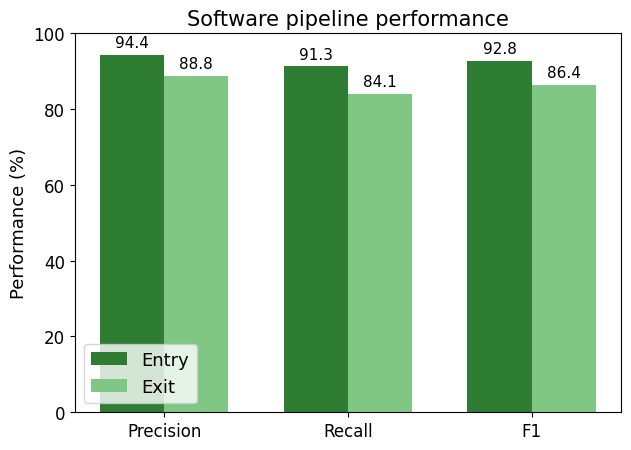

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Data
entry = [94.4, 91.3, 92.8]
exit_ = [88.8, 84.1, 86.4]

labels = ["Precision", "Recall", "F1"]
x = np.arange(len(labels))
width = 0.35

# Colors (green theme)
entry_color = "#2E7D32"   # dark green
exit_color = "#81C784"    # light green

plt.figure(figsize=(6.5, 4.7))

bars1 = plt.bar(x - width/2, entry, width, label="Entry", color=entry_color)
bars2 = plt.bar(x + width/2, exit_, width, label="Exit", color=exit_color)

plt.xticks(x, labels)
plt.ylabel("Performance (%)")
plt.ylim(0, 100)
plt.title("Software pipeline performance")

# 🔥 FIXED LEGEND
plt.legend()

# Value labels
for bars in [bars1, bars2]:
    for bar in bars:
        val = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            val + 1.2,
            f"{val:.1f}",
            ha="center",
            va="bottom",
            fontsize=11
        )

plt.tight_layout()
plt.show()